## Project 4: Accuracy and Beyond: Instagram Reels Recommendation System  

**Course:** DATA 612 – Recommender Systems<br>
**Student:** Inna Yedzinovich


### Introduction

In this project, I extend previous recommender system work by applying recommendation techniques to a new dataset: Instagram Reels.

Unlike traditional datasets such as MovieLens, this dataset does not contain explicit user ratings. Instead, engagement metrics such as likes and comments are used as a proxy for user preference.

The goal of this project is to:

1. Compare multiple recommendation approaches:
   - Content-Based Filtering  
   - Popularity-Based Recommendation  
   - Hybrid Model  

2. Introduce a business-oriented improvement:
   - Diversity (reducing repetitive recommendations)

3. Evaluate performance before and after introducing diversity.

---

### Dataset

The dataset used in this project is an Instagram Reels dataset from Kaggle:
 - https://www.kaggle.com/datasets/lokeshbhaskarnr/instagram-reels-analysis-dataset  

The dataset includes the following features:

- description  
- hashtags  
- account_id  
- likes  
- comments  
- topic  

In this context: 
- likes + comments ≈ user engagement (proxy for preference)
- topic ≈ content category

---

Since the dataset does not contain user ratings, traditional metrics such as RMSE and MAE cannot be applied. Instead, evaluation is based on engagement (as a proxy for relevance) and diversity of recommendations.

### Data Preparation

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display

In [2]:
df = pd.read_csv("data/instagram_reels_data.csv")
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (1913, 8)


,Unnamed: 0,description,hashtags,url,account_id,likes,comments,topic
0,0.0,Day 68,#reels #fyp #barcelona #realmadrid,https://www.instagram.com/reels/C6C3zbfCrj1/,dancing_chicken.daily,37.2K,120,Sports
1,1.0,NaN,vana.cumm · Original audio,https://www.instagram.com/reels/C6BtBA_x_E-/,vana.cumm,96.7K,411,NaN
2,2.0,Tag someone 🤡❤️..........,#reelsindia #reelsvideos #instareels #instagra...,https://www.instagram.com/reels/C5D0YihJ_9k/,quoteswriter___,428K,12.8K,Relationships
3,3.0,Yen anthira 🤣🤣,#reels #comedy #kannadareels #yashwanthshetty ...,https://www.instagram.com/reels/C27EgB2LJKf/,yashwanth_shettyy,260K,"1,137",Comedy
4,4.0,Do you remember this guy??? go,#pokemon #pokemongo #nostalgia #retrogaming,https://www.instagram.com/reels/C2qqhuJxqdM/,doc.nostalgia,2.1M,"1,939",Gaming


---
### Engagement Data, Engagement Score and Exploratory Analysis
Cleaning engagement data converts text-based interaction counts into numerical values, and the engagement score combines likes and comments into a single metric used as a proxy for user preference.

After cleaning, engagement values are expressed as absolute counts ranging from small numbers to millions. Since this creates a highly skewed scale, normalization is applied to convert values into a comparable range between 0 and 1. For example, a reel with 1,000,000 interactions becomes 1.0, while a reel with 120 interactions becomes a very small value close to 0. This allows the model to compare items fairly without being dominated by extremely large values.

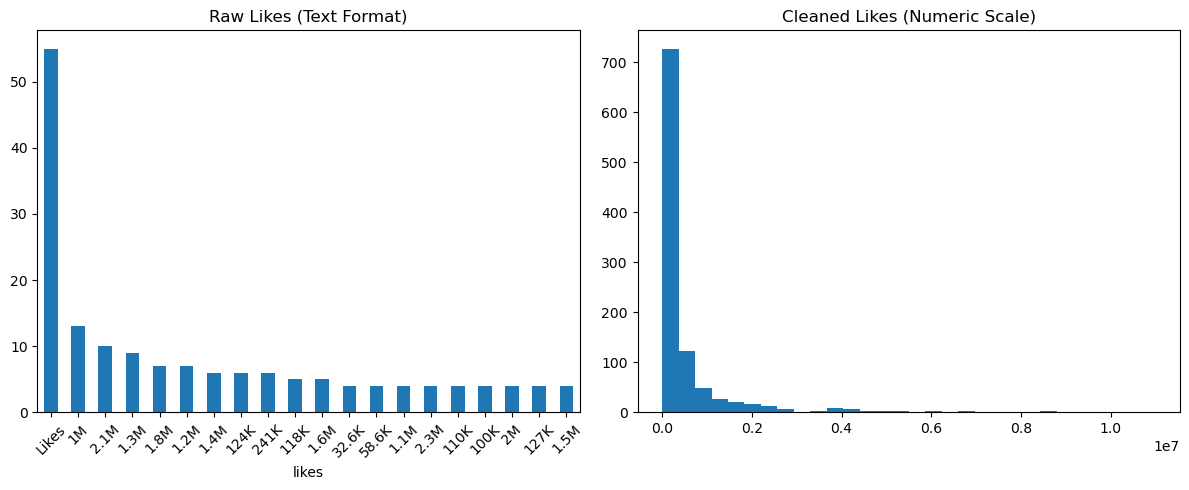

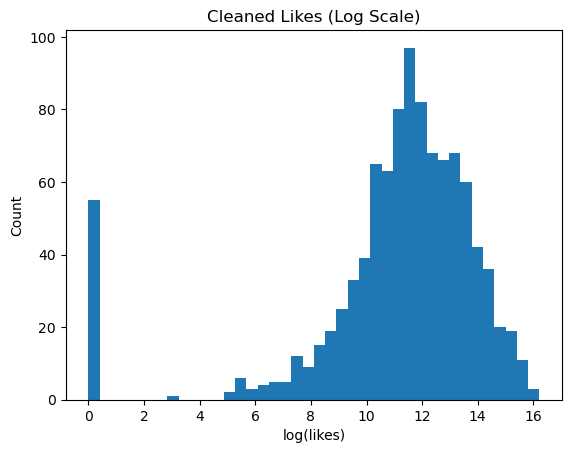

Text(0.5, 1.0, 'Likes vs Comments')

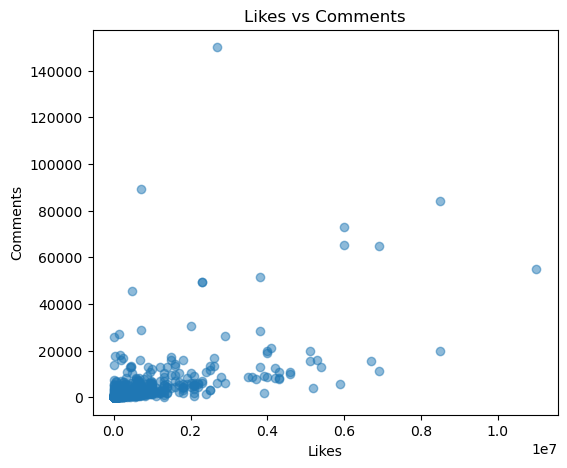

In [3]:
def convert_to_number(x):
    if isinstance(x, str):
        x = x.replace(',', '')
        if 'K' in x:
            return float(x.replace('K', '')) * 1000
        elif 'M' in x:
            return float(x.replace('M', '')) * 1000000
    try:
        return float(x)
    except:
        return 0

df['likes_numeric'] = df['likes'].apply(convert_to_number)
df['comments_numeric'] = df['comments'].apply(convert_to_number)

df[['likes','likes_numeric','comments','comments_numeric']].head()

plt.figure(figsize=(12,5))

# Before (raw likes as text → just counts categories)
plt.subplot(1,2,1)
df['likes'].value_counts().head(20).plot(kind='bar')
plt.title("Raw Likes (Text Format)")
plt.xticks(rotation=45)

# After (numeric)
plt.subplot(1,2,2)
plt.hist(df['likes_numeric'], bins=30)
plt.title("Cleaned Likes (Numeric Scale)")

plt.tight_layout()
plt.show()

# log version 
plt.hist(np.log1p(df['likes_numeric']), bins=40)
plt.title("Cleaned Likes (Log Scale)")
plt.xlabel("log(likes)")
plt.ylabel("Count")

plt.show()

# Likes vs Comments 
plt.figure(figsize=(6,5))

plt.scatter(df['likes_numeric'], df['comments_numeric'], alpha=0.5)
plt.xlabel("Likes")
plt.ylabel("Comments")
plt.title("Likes vs Comments")


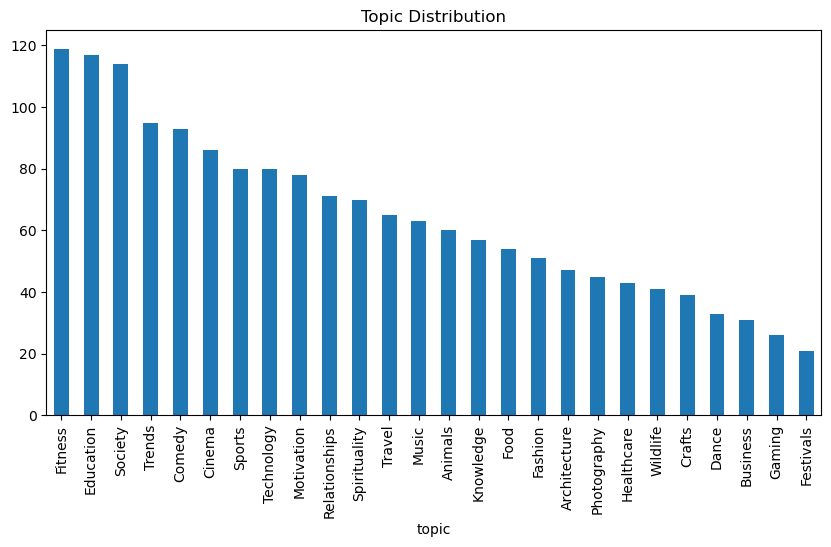

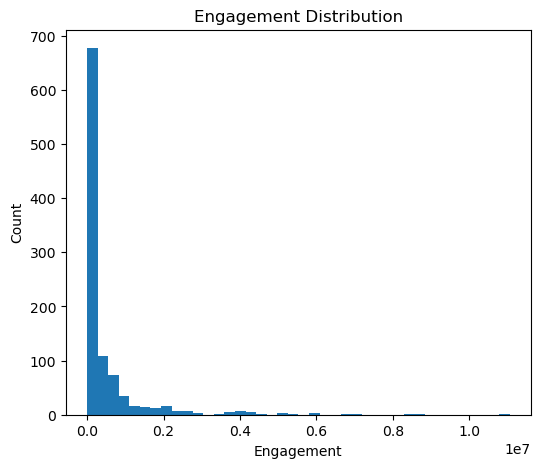

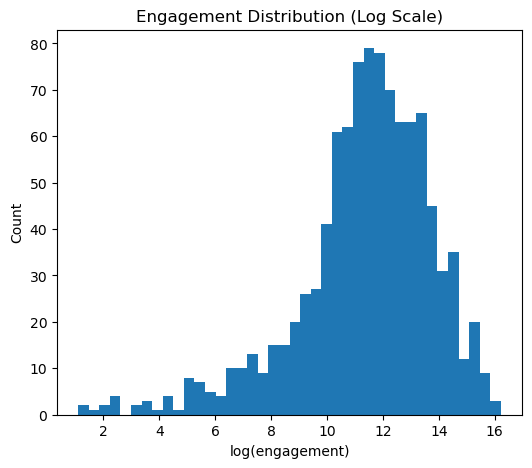

In [4]:
# Topic Distribution 
df['topic'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Topic Distribution')
plt.show()

# Engagement Score
df['engagement'] = df['likes_numeric'] + df['comments_numeric']
df[['engagement']].head()

# Engagement Distribution
plt.figure(figsize=(6,5))

plt.hist(df['engagement'], bins=40)
plt.title("Engagement Distribution")
plt.xlabel("Engagement")
plt.ylabel("Count")

plt.show()

# Log Scale 
plt.figure(figsize=(6,5))

plt.hist(np.log1p(df['engagement']), bins=40)
plt.title("Engagement Distribution (Log Scale)")
plt.xlabel("log(engagement)")
plt.ylabel("Count")

plt.show()

(P1-P3)The first plot shows that raw likes are stored in text format (e.g., “1M”, “124K”), which is not suitable for analysis, while the cleaned version converts them into consistent numeric values. After applying a log transformation, the engagement distribution becomes more balanced, revealing that most reels have moderate engagement while only a few reach very high popularity. The scatter plot of likes versus comments shows a general positive relationship, where reels with more likes tend to also have more comments. Overall, these visuals confirm that engagement is highly skewed but meaningful, supporting its use as a proxy for user preference.

(P4)More likes usually means more comments, but not always. Some reels go viral and get a lot of comments compared to their likes, while others have many likes but relatively fewer comments.

(P5) The topic distribution shows that a few categories such as Fitness, Education, and Society dominate the dataset, while many other topics appear less frequently, indicating an uneven distribution of content across categories.

(P6-P7) The engagement distribution plot shows that most reels receive very low interaction, while a small number of reels achieve extremely high engagement, resulting in a highly skewed distribution. After applying a log transformation, the distribution becomes more balanced and easier to interpret, revealing that most reels fall within a moderate engagement range. This confirms the typical pattern of social media data, where a few posts go viral while the majority remain less popular. Overall, these visualizations demonstrate the need for transformation and support the use of engagement as a meaningful metric for recommendations

---

### Model Comparison

#### Content-Based Model

The content-based model represents each reel using its hashtags and topic, converting this text into numerical vectors. Recommendations are generated by computing similarity between reels, where items with similar content are considered more relevant.

1. Combine text -> hashtags + topic 
2. Turn text into numbers (bag-of-words)  
3. Compute similarity between reels

[Note]To explain how the content-based model works, a simple example was created where text data is converted into a bag-of-words matrix. Each reel is represented as a vector of word counts, allowing similarity between items to be computed. The similarity matrix shows that reels with similar words have higher similarity scores, forming the basis for content-based recommendations.


                       text
0       fitness gym workout
1  fitness workout training
2       food cooking recipe
   cooking  fitness  food  gym  recipe  training  workout
0        0        1     0    1       0         0        1
1        0        1     0    0       0         1        1
2        1        0     1    0       1         0        0


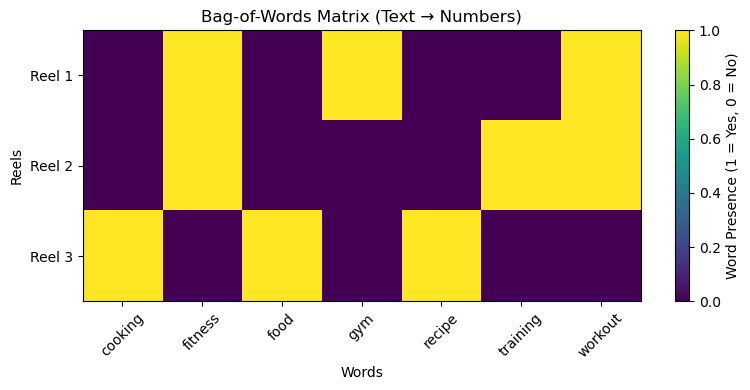

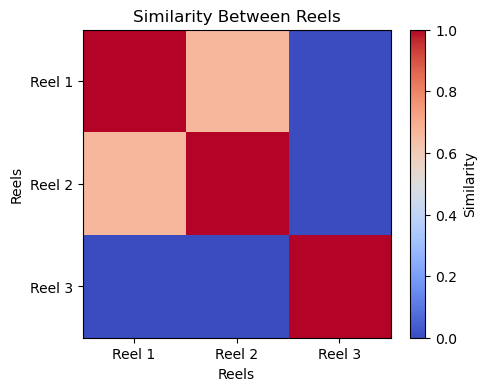

In [5]:
# example on what I am trying to do on a tiny dataset 

data = pd.DataFrame({
    "text": [
        "fitness gym workout",
        "fitness workout training",
        "food cooking recipe"
    ]
})

print(data)

# Convert text -> matrix (bag-of-words)
vectorizer = CountVectorizer()
matrix = vectorizer.fit_transform(data["text"])

matrix_df = pd.DataFrame(
    matrix.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print(matrix_df)

# visual
plt.figure(figsize=(8,4))
plt.imshow(matrix_df, aspect='auto', cmap='viridis')
reel_labels = ["Reel 1", "Reel 2", "Reel 3"]

plt.xticks(range(len(matrix_df.columns)), matrix_df.columns, rotation=45)
plt.yticks(range(len(reel_labels)), reel_labels)

plt.title("Bag-of-Words Matrix (Text → Numbers)")
plt.xlabel("Words")
plt.ylabel("Reels")

plt.colorbar(label="Word Presence (1 = Yes, 0 = No)")

plt.tight_layout()
plt.show()

# Compute similarity
similarity = cosine_similarity(matrix)

similarity_df = pd.DataFrame(similarity)
similarity_df

# matrix visual
plt.figure(figsize=(5,4))

plt.imshow(similarity, cmap='coolwarm', vmin=0, vmax=1)
reel_labels = ["Reel 1", "Reel 2", "Reel 3"]

plt.xticks(range(len(reel_labels)), reel_labels)
plt.yticks(range(len(reel_labels)), reel_labels)

plt.title("Similarity Between Reels")
plt.xlabel("Reels")
plt.ylabel("Reels")

plt.colorbar(label="Similarity")
plt.show()


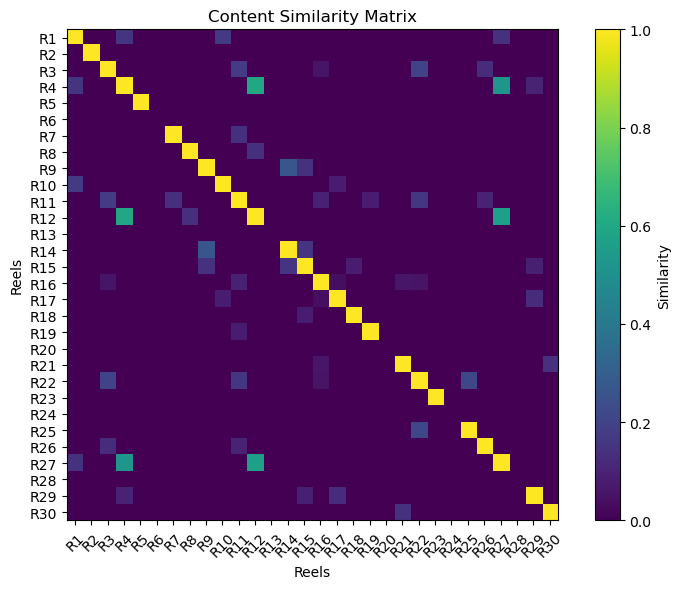

In [6]:
df['content'] = df['hashtags'].fillna('') + ' ' + df['topic'].fillna('')
vectorizer = CountVectorizer()
content_matrix = vectorizer.fit_transform(df['content'])
similarity = cosine_similarity(content_matrix)

# Reel i vs Reel j similarity scores
similarity_df = pd.DataFrame(similarity)
similarity_df.iloc[:5, :5]
similarity_df.head()

plt.figure(figsize=(8,6))

sim = similarity[:30, :30]  # first 30
n = sim.shape[0]
labels = [f"R{i+1}" for i in range(n)]

plt.imshow(sim, 
           cmap='viridis', 
           vmin=0, vmax=1, 
           interpolation='nearest')

plt.xticks(range(n), labels, rotation=45)
plt.yticks(range(n), labels)

plt.title("Content Similarity Matrix")
plt.xlabel("Reels")
plt.ylabel("Reels")

plt.colorbar(label="Similarity")

plt.tight_layout()
plt.show()

---
#### Popularity-Based Model

The popularity-based model recommends reels based on how many likes and comments they receive, assuming that the most popular content is most relevant.

1. Convert interactions -> like + comments (engagement)
2. Rank reels -> highest engagement first
3. Recommend top reels -> most popular content

Key Difference: 
 - Content-Based ->similar content 
 - Popularity -> most popular 

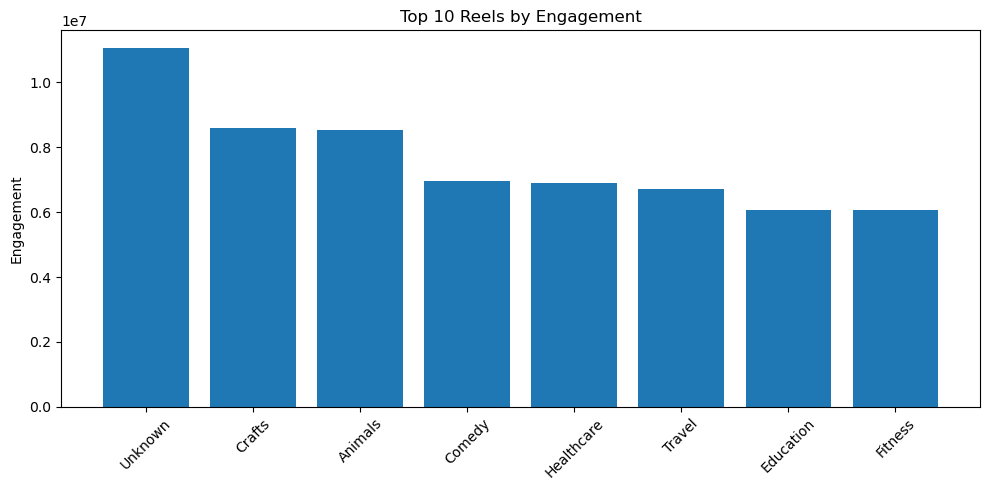

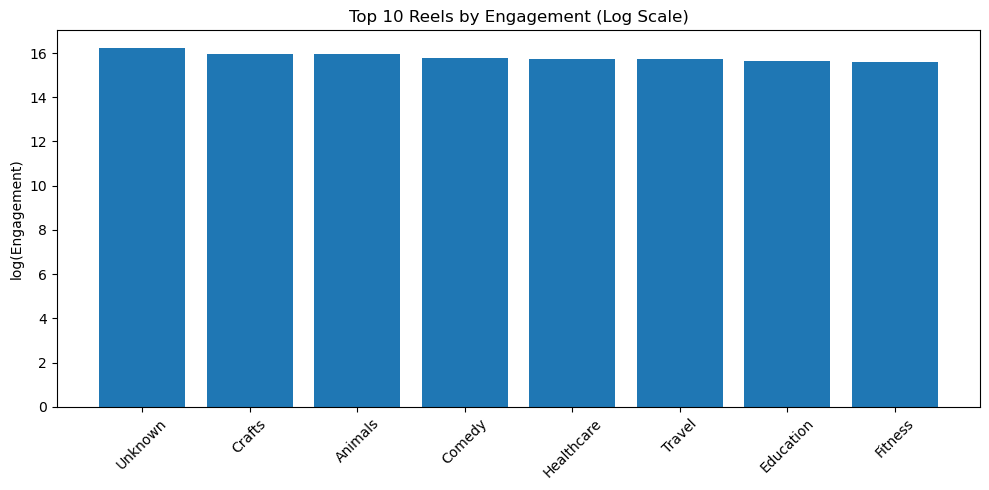

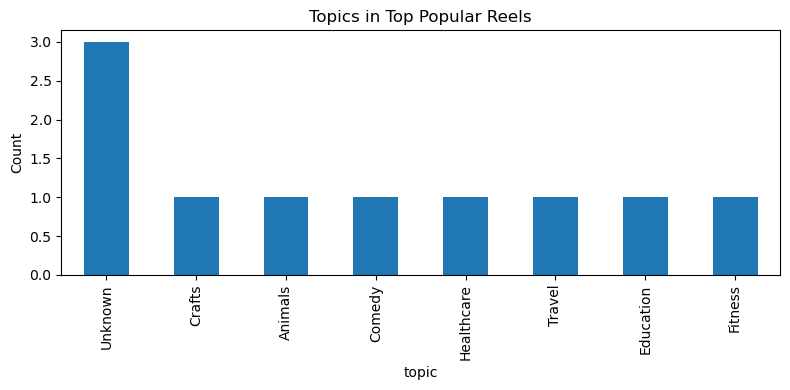

In [7]:
popular_recs = df.sort_values(by='engagement', ascending=False)
popular_recs[['topic', 'likes_numeric', 'comments_numeric', 'engagement']].head()

# visuals
top_reels = popular_recs.head(10).copy()
top_reels['topic'] = top_reels['topic'].fillna("Unknown").astype(str)
top_reels[['topic', 'likes_numeric', 'comments_numeric', 'engagement']]

plt.figure(figsize=(10,5))
plt.bar(top_reels['topic'], top_reels['engagement'])
plt.xticks(rotation=45)
plt.ylabel("Engagement")
plt.title("Top 10 Reels by Engagement")
plt.tight_layout()
plt.show()


plt.figure(figsize=(10,5))
plt.bar(top_reels['topic'], np.log1p(top_reels['engagement']))
plt.xticks(rotation=45)
plt.ylabel("log(Engagement)")
plt.title("Top 10 Reels by Engagement (Log Scale)")

plt.tight_layout()
plt.show()



plt.figure(figsize=(8,4))
top_reels['topic'].value_counts().plot(kind='bar')
plt.title("Topics in Top Popular Reels")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



The plot shows that a few reels have much higher engagement than the rest, meaning they are significantly more popular. Most of the other reels have lower engagement, which creates a big gap between the top and the rest. (Popularity-based model highlights that engagement is highly skewed) 

The topics in the top reels are spread across different categories, but a lot of the “Unknown” label suggests that some data is missing or not labeled properly. 
 
Overall, the model is mainly recommending a small number of very popular reels.

---

#### Hybrid Model

The hybrid model ranks reels using a hybrid_score, which combines how similar a reel is and how popular it is, so the top results are both relevant and well-liked.

The hybrid_score is a combined value that measures how good a reel is by considering both how similar it is to other content and how popular it is. It is calculated by giving more weight to similarity and some weight to engagement, so the final recommendations are both relevant and popular. (hybrid_score = 0.6 * similarity_norm + 0.4 * engagement_norm)

1. Compute similarity -> based on hashtags + topic
2. Compute engagement -> likes + comments
3. Combine both -> weighted hybrid_score
4. Recommend top reels -> highest hybrid_score

Key Idea: 
Content model -> “this looks like what you like”  
Popularity -> “this is popular”  
Hybrid -> “this looks like what you like + people like it”


,topic,engagement_millions,similarity_norm,hybrid_score
114,Education,1.80,1.000,0.665
304,Education,6.07,0.666,0.619
605,Comedy,6.96,0.612,0.619
368,Animals,8.52,0.495,0.605
228,Cinema,0.86,0.953,0.603
744,Education,0.03,1.000,0.601
274,Education,0.02,1.000,0.601
353,Education,0.00,1.000,0.600
221,Education,0.05,0.988,0.595
120,Education,0.01,0.988,0.593


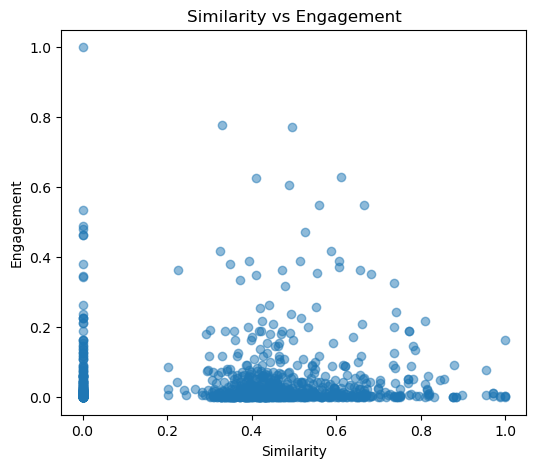

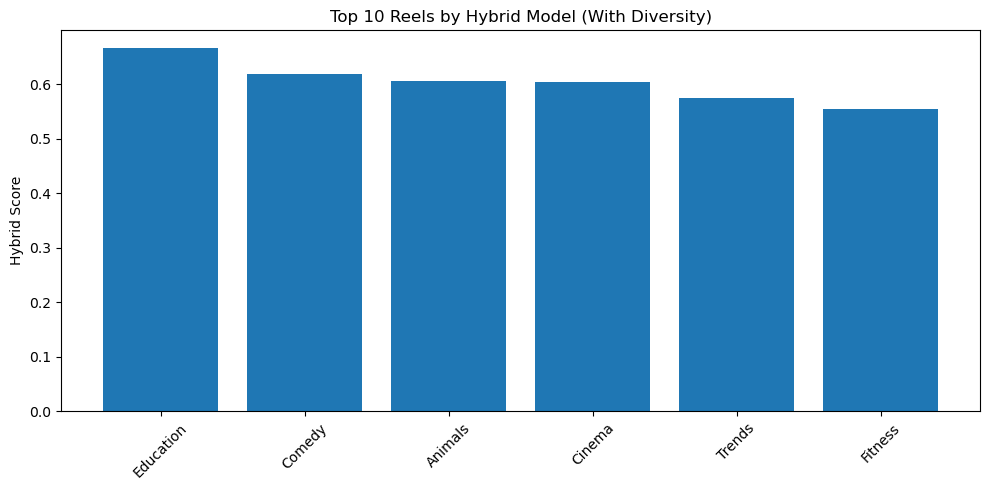

In [8]:
df['engagement_norm'] = df['engagement'] / df['engagement'].max()

similarity_scores = np.sort(similarity, axis=1)[:, -5:].mean(axis=1)
df['similarity_norm'] = similarity_scores / similarity_scores.max()

df['hybrid_score'] = 0.6 * df['similarity_norm'] + 0.4 * df['engagement_norm']

hybrid_recs = df.sort_values('hybrid_score', ascending=False)

# Top 10 recommendations
top_hybrid = hybrid_recs.head(10).copy()
top_hybrid['topic'] = top_hybrid['topic'].fillna("Unknown").astype(str)

# Display table
top_hybrid_display = top_hybrid[['topic', 'engagement', 'similarity_norm', 'hybrid_score']].copy()
top_hybrid_display['engagement_millions'] = (top_hybrid_display['engagement'] / 1_000_000).round(2)
top_hybrid_display['similarity_norm'] = top_hybrid_display['similarity_norm'].round(3)
top_hybrid_display['hybrid_score'] = top_hybrid_display['hybrid_score'].round(3)

display(top_hybrid_display[['topic', 'engagement_millions', 'similarity_norm', 'hybrid_score']])


# visuals

plt.figure(figsize=(6,5))
plt.scatter(df['similarity_norm'], df['engagement_norm'], alpha=0.5)

plt.xlabel("Similarity")
plt.ylabel("Engagement")
plt.title("Similarity vs Engagement")

plt.show()


# NOTE:
# can see that "Education" appears multiple times (4 times),
# meaning the model is recommending very similar content.
# This happens because similar reels receive high similarity scores,
# resulting in LOW diversity.


# Apply diversity constraint
# How? limit how many times the same topic appears to make recommendations more varied. (max 2)

top_hybrid_diverse = hybrid_recs.groupby('topic').head(2).head(10).copy()
top_hybrid_diverse['topic'] = top_hybrid_diverse['topic'].fillna("Unknown").astype(str)

plt.figure(figsize=(10,5))
plt.bar(top_hybrid_diverse['topic'], top_hybrid_diverse['hybrid_score'])

plt.xticks(rotation=45)
plt.ylabel("Hybrid Score")
plt.title("Top 10 Reels by Hybrid Model (With Diversity)")

plt.tight_layout()
plt.show()

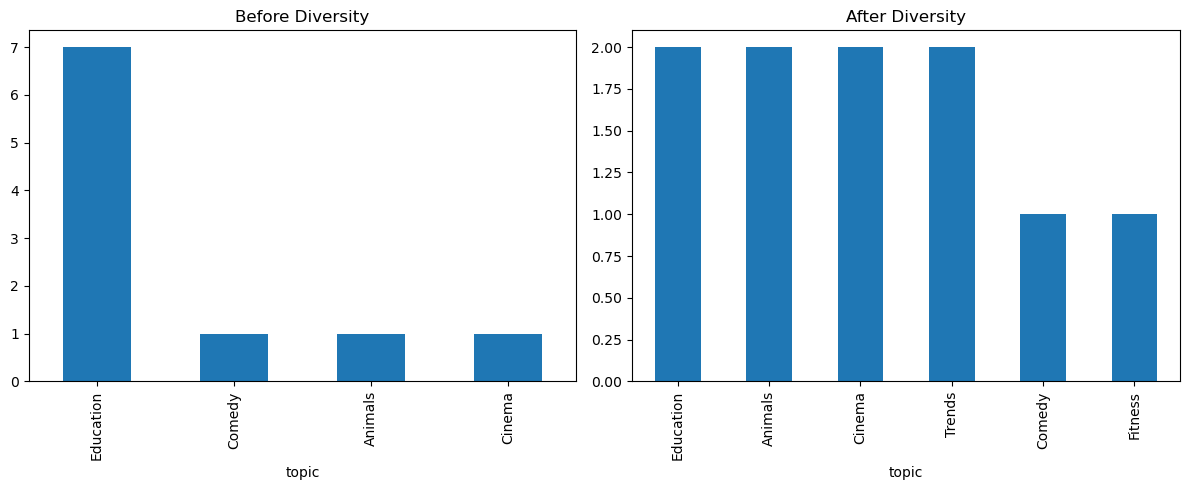

Unique topics BEFORE: 4
Unique topics AFTER: 6
Avg Hybrid Score BEFORE: 0.61
Avg Hybrid Score AFTER: 0.594


In [9]:
# Comparison

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
top_hybrid['topic'].value_counts().plot(kind='bar')
plt.title("Before Diversity")

plt.subplot(1,2,2)
top_hybrid_diverse['topic'].value_counts().plot(kind='bar')
plt.title("After Diversity")

plt.tight_layout()
plt.show()

print("Unique topics BEFORE:", top_hybrid['topic'].nunique())
print("Unique topics AFTER:", top_hybrid_diverse['topic'].nunique())

print("Avg Hybrid Score BEFORE:", round(top_hybrid['hybrid_score'].mean(), 3))
print("Avg Hybrid Score AFTER:", round(top_hybrid_diverse['hybrid_score'].mean(), 3))

P1 shows that similarity and engagement do not always match, meaning some reels are relevant but not popular, while others are popular but not very similar. This is why the hybrid model is needed to balance both factors.

Another observation is that “Education” appears many times, showing that the similarity model tends to group very similar content together. This happens because reels with similar words get high similarity scores, which leads to repetitive and less diverse recommendations. To fix this, a diversity constraint is added to include a wider range of topics.

P2 shows the effect of this change. After applying diversity, the recommendations include more different topics instead of repeating the same one. The number of unique topics increases from 4 to 6, meaning now I have more variety in the recommendations. At the same time, the average hybrid score only drops slightly from 0.61 to 0.594, which means the overall quality of recommendations remains almost the same.

These numbers show that diversity is improved without losing much performance, making the recommender system more balanced and useful.

Text(0, 0.5, 'Engagement')

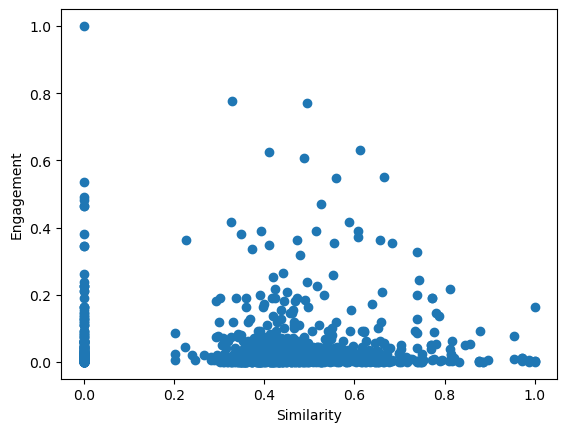

In [10]:
# Correlation plot
plt.scatter(df['similarity_norm'], df['engagement_norm'])

plt.xlabel("Similarity")
plt.ylabel("Engagement")

This plot shows that similarity and engagement don’t really move together, meaning a reel can be very similar but still not popular. That’s why both need to be combined in the hybrid model.

---

### Model Comparison: Content-Based, Popularity-Based and Hybrid

In this section, I compare the performance of content-based, popularity-based, and hybrid recommendation models. Each model is evaluated based on engagement (as a proxy for quality) and topic diversity. I also analyze the effect of adding a diversity constraint to the hybrid model and how it impacts the overall recommendations.

----- BEFORE DIVERSITY -----
Content avg engagement: 339432.4
Popularity avg engagement: 7220718.7
Hybrid avg engagement: 2434071.8

Unique topics:
Content: 4
Popularity: 8
Hybrid: 4

----- AFTER DIVERSITY (Hybrid only) -----
Hybrid (diverse) avg engagement: 3774468.4
Hybrid (diverse) topics: 6


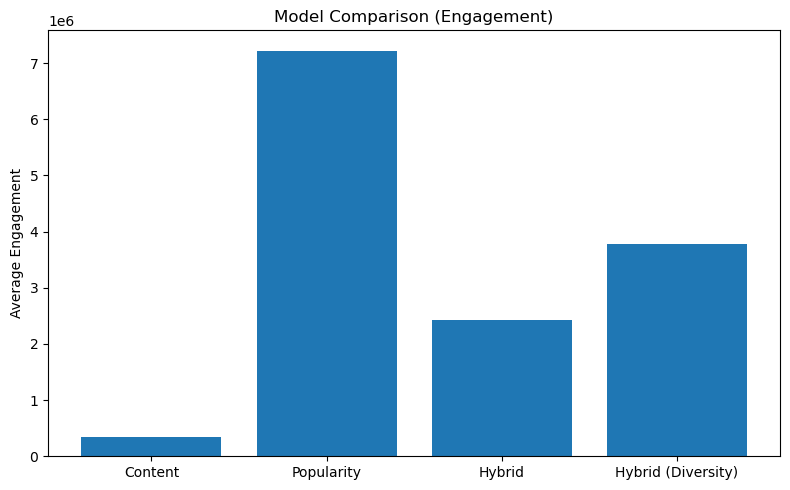

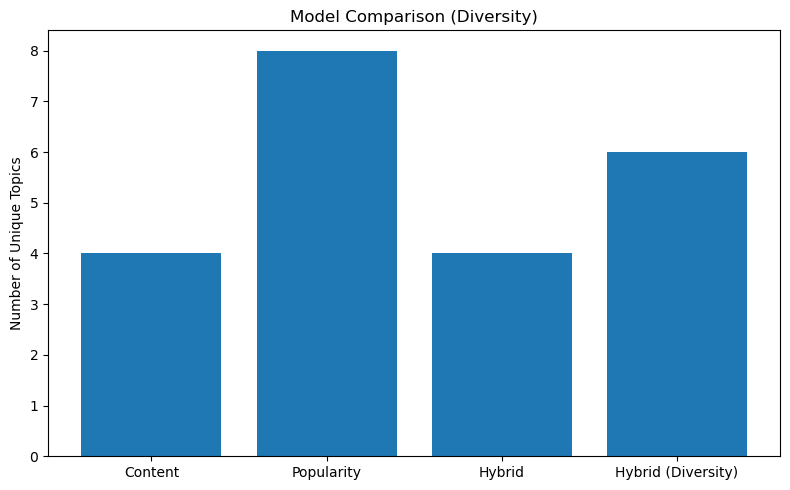

In [11]:
# Compute metrics for all 3 models

# Content-Based (approx top using similarity)
content_scores = similarity.mean(axis=1)
df['content_score'] = content_scores / content_scores.max()

content_recs = df.sort_values('content_score', ascending=False)
top_content = content_recs.head(10).copy()

# Popularity
top_popularity = popular_recs.head(10).copy()

# Hybrid
top_hybrid = hybrid_recs.head(10).copy()
top_hybrid_div = top_hybrid_diverse.copy()

# clean topics
for d in [top_content, top_popularity, top_hybrid, top_hybrid_div]:
    d['topic'] = d['topic'].fillna("Unknown").astype(str)

print("----- BEFORE DIVERSITY -----")

print("Content avg engagement:", top_content['engagement'].mean())
print("Popularity avg engagement:", top_popularity['engagement'].mean())
print("Hybrid avg engagement:", top_hybrid['engagement'].mean())

print("\nUnique topics:")
print("Content:", top_content['topic'].nunique())
print("Popularity:", top_popularity['topic'].nunique())
print("Hybrid:", top_hybrid['topic'].nunique())

print("\n----- AFTER DIVERSITY (Hybrid only) -----")
print("Hybrid (diverse) avg engagement:", top_hybrid_div['engagement'].mean())
print("Hybrid (diverse) topics:", top_hybrid_div['topic'].nunique())    

# visual

# engagement comparison
models = ["Content", "Popularity", "Hybrid", "Hybrid (Diversity)"]

engagement_scores = [
    top_content['engagement'].mean(),
    top_popularity['engagement'].mean(),
    top_hybrid['engagement'].mean(),
    top_hybrid_div['engagement'].mean()
]

plt.figure(figsize=(8,5))
plt.bar(models, engagement_scores)

plt.ylabel("Average Engagement")
plt.title("Model Comparison (Engagement)")

plt.tight_layout()
plt.show()


# diversity comparison 
div_scores = [
    top_content['topic'].nunique(),
    top_popularity['topic'].nunique(),
    top_hybrid['topic'].nunique(),
    top_hybrid_div['topic'].nunique()
]

plt.figure(figsize=(8,5))
plt.bar(models, div_scores)

plt.ylabel("Number of Unique Topics")
plt.title("Model Comparison (Diversity)")

plt.tight_layout()
plt.show()

The content-based model gives low engagement and repeats topics. The popularity model gives very high engagement but is not personalized. The hybrid model is more balanced, but still repeats some topics.

After adding diversity, the hybrid model improves by increasing the number of topics from 4 to 6, while also increasing engagement. This shows that I can make recommendations more varied without losing performance.

Overall, the hybrid model with diversity works best because it balances similarity, popularity, and diversity.


### Additional Evaluation Metrics

Besides engagement and topics, I also looked at a few other metrics.

1. Intra-list diversity
2. Catalog Coverage
3. Novelty

These metrics help better understand how the recommender behaves, not just based on engagement.

#### Intra-list diversity 
Intra-list diversity shows how different the recommended reels are from each other. If they are very similar, the value is low, and if they are more varied, the value is higher.

Intra-list Diversity:
Content: 0.65
Hybrid: 0.656
Hybrid (Diversity): 0.93


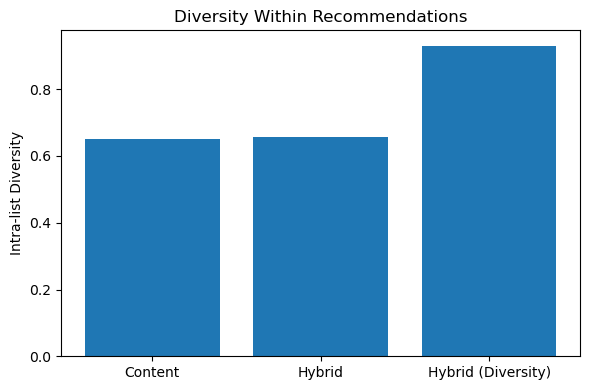

In [12]:
def intra_list_diversity(indices, sim):
    values = []
    for i in range(len(indices)):
        for j in range(i + 1, len(indices)):
            values.append(sim[indices[i], indices[j]])
    return 1 - np.mean(values)

ild_content = intra_list_diversity(top_content.index.tolist(), similarity)
ild_hybrid = intra_list_diversity(top_hybrid.index.tolist(), similarity)
ild_div = intra_list_diversity(top_hybrid_diverse.index.tolist(), similarity)

print("Intra-list Diversity:")
print("Content:", round(ild_content, 3))
print("Hybrid:", round(ild_hybrid, 3))
print("Hybrid (Diversity):", round(ild_div, 3))

# visual 
models = ["Content", "Hybrid", "Hybrid (Diversity)"]
values = [ild_content, ild_hybrid, ild_div]

plt.figure(figsize=(6,4))
plt.bar(models, values)

plt.ylabel("Intra-list Diversity")
plt.title("Diversity Within Recommendations")

plt.tight_layout()
plt.show()


#### Catalog Coverage
Catalog Coverage shows how much of the dataset is used in the recommendations. Higher coverage means the model shows more different items instead of repeating the same ones.


Catalog Coverage:
Content: 0.0052
Hybrid: 0.0052


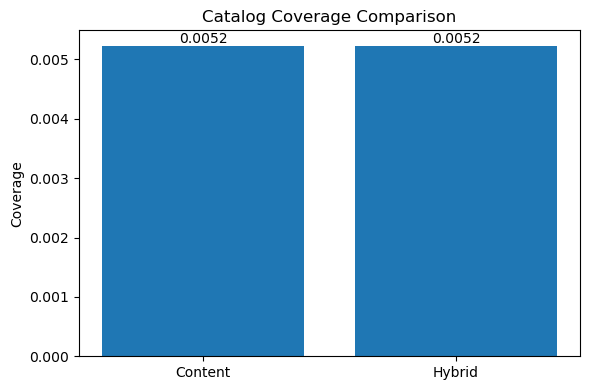

In [13]:
print("\nCatalog Coverage:")
print("Content:", round(len(top_content) / len(df), 4))
print("Hybrid:", round(len(top_hybrid) / len(df), 4))

# visual
models_cov = ["Content", "Hybrid"]
coverage_values = [
    len(top_content) / len(df),
    len(top_hybrid) / len(df)
]

plt.figure(figsize=(6,4))
bars = plt.bar(["Content", "Hybrid"], coverage_values)

plt.ylabel("Coverage")
plt.title("Catalog Coverage Comparison")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f"{height:.4f}",
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Novelty
Novelty shows whether the model recommends less popular content or mostly viral reels.


Novelty:
Content: 0.969
Hybrid: 0.78
Hybrid (Diversity): 0.659


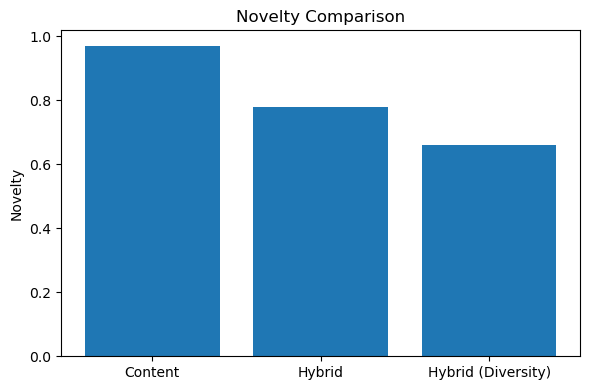

In [14]:
print("\nNovelty:")
print("Content:", round(1 - top_content['engagement_norm'].mean(), 3))
print("Hybrid:", round(1 - top_hybrid['engagement_norm'].mean(), 3))
print("Hybrid (Diversity):", round(1 - top_hybrid_diverse['engagement_norm'].mean(), 3))

# visual 
models_nov = ["Content", "Hybrid", "Hybrid (Diversity)"]
nov_values = [
    1 - top_content['engagement_norm'].mean(),
    1 - top_hybrid['engagement_norm'].mean(),
    1 - top_hybrid_diverse['engagement_norm'].mean()
]

plt.figure(figsize=(6,4))
plt.bar(models_nov, nov_values)

plt.ylabel("Novelty")
plt.title("Novelty Comparison")

plt.tight_layout()
plt.show()

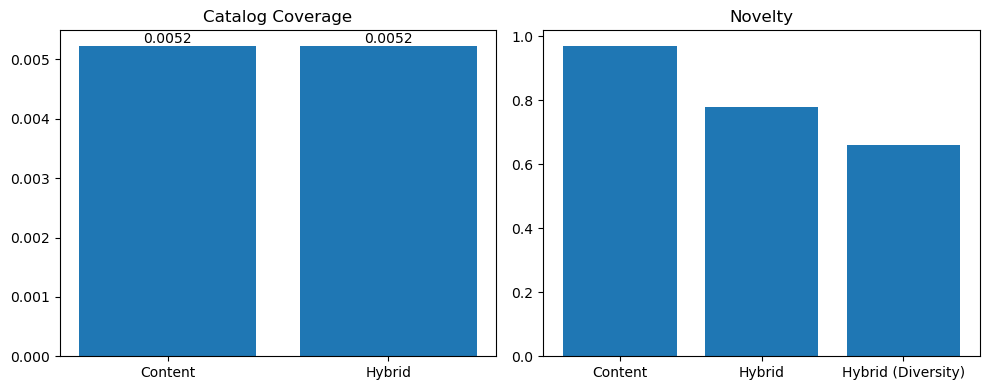

In [15]:
# combined plot

plt.figure(figsize=(10,4))

# coverage (keep real values)
plt.subplot(1,2,1)
bars = plt.bar(models_cov, coverage_values)
plt.title("Catalog Coverage")

for i, bar in enumerate(bars):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{coverage_values[i]:.4f}",
             ha='center', va='bottom')

# novelty
plt.subplot(1,2,2)
plt.bar(models_nov, nov_values)
plt.title("Novelty")

plt.tight_layout()
plt.show()


Looking at all the additional metrics, we can see that the content-based and hybrid models behave similarly in intra-list diversity, which is expected because the hybrid model still relies heavily on similarity, so it recommends similar items.

The catalog coverage is identical for the content-based and hybrid models because both recommend the same number of items, so they cover the same portion of the dataset.

The main differences appear in novelty and diversity. The content-based model has higher novelty because it recommends less popular items, while the hybrid model includes more popular content. After adding the diversity constraint, the hybrid model improves significantly in intra-list diversity, making the recommendations much more varied and less repetitive.

Overall, the hybrid model with diversity performs best because it creates a better balance between relevance, popularity, and variety.

### Online Evaluation and Conclusion

In a real system, I would evaluate the models using online methods like A/B testing, where different users see different recommendations. Instead of engagement used in this project, I would measure metrics like click-through rate (CTR) and watch time to see how users interact with the content.

For example, higher CTR means users click more on recommendations, and longer watch time means they stay engaged. I could also measure whether more diverse recommendations keep users interested over time.

Since this dataset does not include real user interactions, I used offline metrics, but online evaluation would give a more realistic measure of performance.

Overall, the results of this project show that different models have different strengths. The content-based model focuses on similarity but results in low engagement and repeated topics. The popularity-based model achieves very high engagement but lacks personalization. The hybrid model balances both factors, but still has limited diversity.

After introducing a diversity constraint, the hybrid model improved by increasing the number of unique topics from 4 to 6, while also increasing engagement. This shows that it is possible to improve recommendation variety without sacrificing performance.

In conclusion, the hybrid model with diversity performed the best, as it provided a balance between relevance, popularity, and variety, making the recommendations more effective and useful.